**Introduction:**

**Metric:**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV containing facilities and their corresponding neighborhoods
df_facilities = pd.read_csv('https://data.wprdc.org/datastore/dump/fbb50b02-2879-47cd-abea-ae697ec05170')
# CSV containg information about neighborhoods including area
df_area = pd.read_csv('https://data.wprdc.org/datastore/dump/668d7238-cfd2-492e-b397-51a6e74182ff')

In [18]:
# Get the neighborhood and square miles isolated
area = df_area[['hood','sqmiles']]
area.columns = ['neighborhood', 'sqmiles']
print(area.sort_values(by='sqmiles', ascending=False))

                neighborhood   sqmiles
80       Squirrel Hill South  2.676605
24                 Brookline  2.088930
21  Lincoln-Lemington-Belmar  1.818101
25                      Hays  1.745098
51                   Carrick  1.669530
..                       ...       ...
32            Allegheny West  0.144794
50            Chartiers City  0.134015
18         Arlington Heights  0.127234
41                Friendship  0.106191
67                Mt. Oliver  0.103298

[90 rows x 2 columns]


In [19]:
# Get the neighborhood and number of facilities isolated
counts_df = df_facilities['neighborhood'].value_counts().reset_index()
counts_df.columns = ['neighborhood', 'num_facilities']
print(counts_df)

            neighborhood  num_facilities
0          Highland Park              30
1    Squirrel Hill South              29
2            Perry North              20
3              Brookline              19
4         Strip District              15
..                   ...             ...
70            Glen Hazel               1
71               Larimer               1
72  California-Kirkbride               1
73    Point Breeze North               1
74           Middle Hill               1

[75 rows x 2 columns]


In [20]:
# Merge the two dataframes and calculate the number of facilies per mile
final_df = pd.merge(counts_df, area[['neighborhood', 'sqmiles']], on='neighborhood', how='inner')
final_df['density'] = final_df['num_facilities'] / final_df['sqmiles']
#final_df = final_df.sort_values('density', ascending=False)
final_df = final_df.sort_values('num_facilities', ascending=False)
final_df.head(10)


,neighborhood,num_facilities,sqmiles,density
0,Highland Park,30,1.169860,25.644092
1,Squirrel Hill South,29,2.676605,10.834619
2,Perry North,20,1.209913,16.530114
3,Brookline,19,2.088930,9.095567
4,Strip District,15,0.608189,24.663404
5,Hazelwood,14,1.605243,8.721423
6,Brighton Heights,14,1.117022,12.533321
7,Carrick,12,1.669530,7.187652
8,Lincoln-Lemington-Belmar,11,1.818101,6.050268
9,South Side Slopes,11,0.723060,15.213119


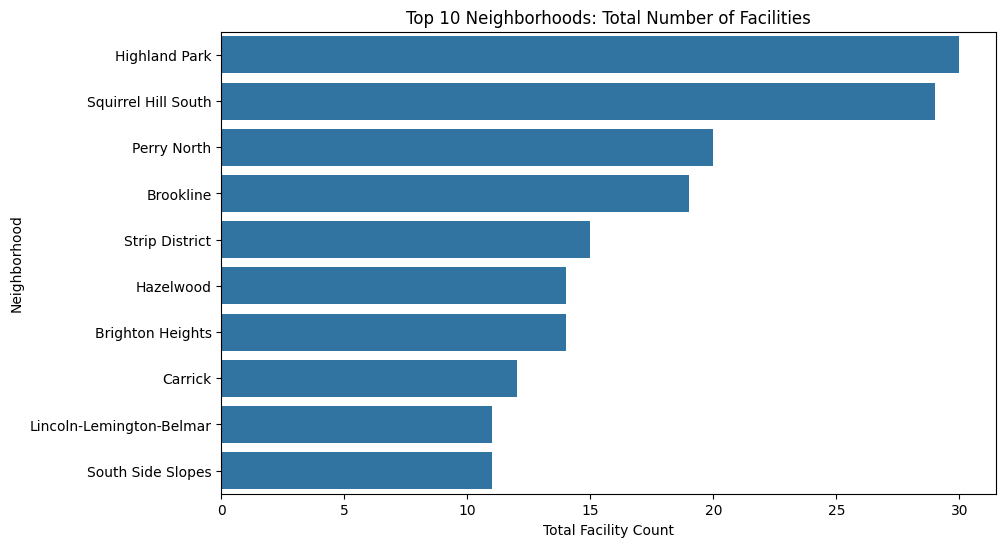

In [26]:
# Plot top ten neighborhoods by facilites
top_10_total = final_df.nlargest(10, 'num_facilities')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_total, x='num_facilities', y='neighborhood')
plt.title('Top 10 Neighborhoods: Total Number of Facilities')
plt.xlabel('Total Facility Count')
plt.ylabel('Neighborhood')
plt.show()

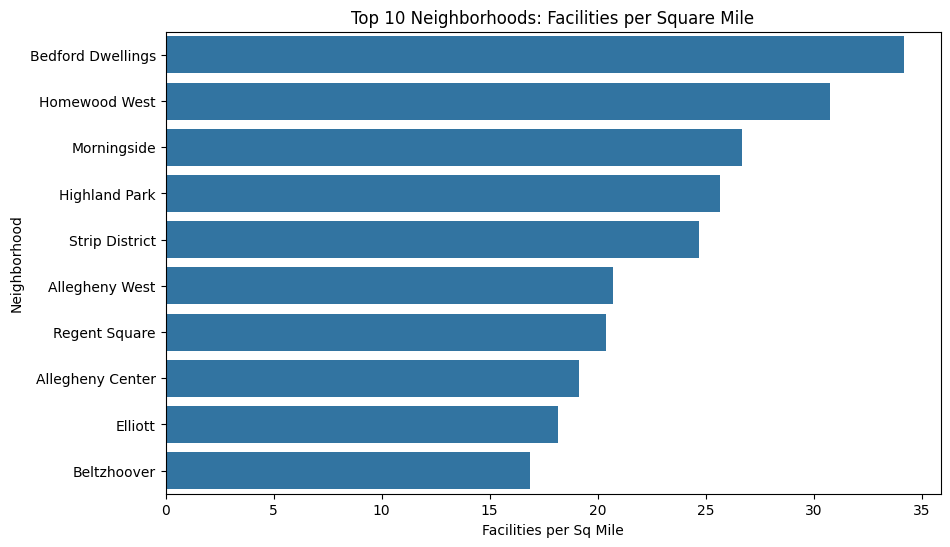

In [23]:
# Plot top ten neighborhoods by facilites per square mile
top_10_density = final_df.nlargest(10, 'density')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_density, x='density', y='neighborhood')
plt.title('Top 10 Neighborhoods: Facilities per Square Mile')
plt.xlabel('Facilities per Sq Mile')
plt.ylabel('Neighborhood')
plt.show()

**Best Neighborhood:**

**Conclusion:**

Luke:

Henry:

Adiva: